In [2]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostRegressor
from sklearn.feature_selection import RFE
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, GridSearchCV, GroupShuffleSplit, RandomizedSearchCV, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler, FunctionTransformer, PolynomialFeatures, RobustScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor, plot_importance, DMatrix, train
from lightgbm import LGBMRegressor
import shap
from scipy.stats import zscore
from scipy.spatial import cKDTree
import os
import fiona
from geopy.distance import geodesic

In [3]:
doubs_data = gpd.read_file("../datasets_par_departement/departement-25-doubs-original.geojson")
caserne = gpd.read_file("../data/caserne/2024_06_21_CIS.shp")
compagnies = gpd.read_file("../data/caserne/2024_06_21_Compagnies.shp")
meteo_doubs = gpd.read_file("../data/meteo/meteostat_doubs.csv")
firepoint_1 = gpd.read_file("../data/hexagones_firepoint_1.geojson")
firepoint_2 = gpd.read_file("../data/hexagones_firepoint_2.geojson")
firepoint_3 = gpd.read_file("../data/hexagones_firepoint_3.geojson")

In [4]:
doubs_data.columns

Index(['hex_id', 'raison_sortie', 'date_debut', 'date_fin', 'label', 'year',
       'date', 'departement', 'duree_minutes', 'geometry'],
      dtype='object')

In [3]:
def calculer_duree(data, colonne_debut, colonne_fin):
    data[colonne_debut] = pd.to_datetime(data[colonne_debut], errors='coerce')
    data[colonne_fin] = pd.to_datetime(data[colonne_fin], errors='coerce')

    data['duree'] = data[colonne_fin] - data[colonne_debut]

    return data

def cyclical_encoding(X, max_value):
    return np.column_stack((
        np.sin(2 * np.pi * X / max_value),
        np.cos(2 * np.pi * X / max_value)
    ))

def season_encoding(month):
    if month in [12, 1, 2]:
        return 0  # Hiver
    elif month in [3, 4, 5]:
        return 1  # Printemps
    elif month in [6, 7, 8]:
        return 2  # Été
    else:
        return 3  # Automne

def remove_highly_correlated_features(X, threshold=0.85):
    corr_matrix = X.corr().abs()  # Matrice de corrélation en valeur absolue
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))  # Partie supérieure

    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]  # Colonnes à supprimer
    print(f"🛑 Suppression de {len(to_drop)} features corrélées: {to_drop}")

    return X.drop(columns=to_drop)


doubs_data = calculer_duree(doubs_data, 'date_debut', 'date_fin')
doubs_data['centroid'] = doubs_data.geometry.centroid
doubs_data['centroid_lon'] = doubs_data['centroid'].x
doubs_data['centroid_lat'] = doubs_data['centroid'].y
doubs_data['date_debut'] = pd.to_datetime(doubs_data['date_debut'], errors='coerce')
doubs_data['hour'] = doubs_data['date_debut'].dt.hour
doubs_data['date'] = pd.to_datetime(doubs_data['date'], errors='coerce')
doubs_data['month'] = doubs_data['date'].dt.month
doubs_data['weekday'] = doubs_data['date'].dt.weekday
doubs_data['duree_minutes'] = pd.to_timedelta(doubs_data['duree']).dt.total_seconds() / 60

Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.



In [4]:
doubs_data['date_debut'] = pd.to_datetime(doubs_data['date_debut'])
meteo_doubs['creneau'] = pd.to_datetime(meteo_doubs['creneau'])

doubs_data = doubs_data.sort_values('date_debut')
meteo_doubs = meteo_doubs.sort_values('creneau')

doubs_meteo = pd.merge_asof(
    doubs_data,
    meteo_doubs,
    left_on='date_debut',
    right_on='creneau',
    direction='nearest',
    suffixes=('', '_meteo')
)

tree = cKDTree(meteo_doubs[['latitude', 'longitude']].values)
distances, indices = tree.query(doubs_meteo[['centroid_lat', 'centroid_lon']].values)

cols_to_keep = [col for col in meteo_doubs.columns if col not in ['index', 'creneau', 'year', 'latitude', 'longitude']]
for col in cols_to_keep:
    if col not in doubs_data.columns:
        doubs_meteo[col] = meteo_doubs.iloc[indices][col].values

doubs_meteo = doubs_meteo[[col for col in doubs_meteo.columns if not col.endswith('_meteo')]]

doubs_meteo.drop(columns=['creneau'], inplace=True)

In [5]:
cols_to_drop = [
    'raison_sortie', 'label', 'departement', 'duree',
    'centroid', 'index', 'longitude', 'latitude'
]

doubs_meteo = doubs_meteo.drop(columns=[col for col in cols_to_drop if col in doubs_meteo.columns])

In [6]:
doubs_meteo.shape

(2965, 59)

In [7]:
doubs_meteo.columns

Index(['hex_id', 'date_debut', 'date_fin', 'year', 'date', 'duree_minutes',
       'geometry', 'centroid_lon', 'centroid_lat', 'hour', 'month', 'weekday',
       'temp', 'dwpt', 'rhum', 'prcp', 'snow', 'wdir', 'wspd', 'pres',
       'prec24h', 'snow24h', 'prec24h12', 'snow24h12', 'temp16', 'dwpt16',
       'rhum16', 'prcp16', 'wdir16', 'wspd16', 'prec24h16', 'snow24h16',
       'temp12', 'dwpt12', 'rhum12', 'prcp12', 'wdir12', 'wspd12', 'temp15h',
       'rhum15h', 'temp12h', 'rhum12h', 'temp24max', 'prec24veille',
       'sum_rain_last_7_days', 'sum_snow_last_7_days',
       'sum_consecutive_rainfall', 'dc', 'days_since_rain', 'ffmc', 'dmc',
       'isi', 'bui', 'fwi', 'daily_severity_rating', 'nesterov', 'munger',
       'kbdi', 'angstroem'],
      dtype='object')

In [8]:
doubs_meteo.head()

,hex_id,date_debut,date_fin,year,date,duree_minutes,geometry,centroid_lon,centroid_lat,hour,...,ffmc,dmc,isi,bui,fwi,daily_severity_rating,nesterov,munger,kbdi,angstroem
0,871f820aaffffff,2014-10-02 14:08:53,2014-10-02 19:54:25,2014.0,2014-10-02,345.533333,"POLYGON ((6.21735 46.89696, 6.21925 46.88490, ...",6.233937,46.892889,14,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,871f82d61ffffff,2014-10-03 19:33:59,2014-10-03 19:55:31,2014.0,2014-10-03,21.533333,"POLYGON ((5.79096 47.26562, 5.79292 47.25365, ...",5.807597,47.261659,19,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,871f82d61ffffff,2014-10-04 19:24:49,2014-10-04 19:59:02,2014.0,2014-10-04,34.216667,"POLYGON ((5.79096 47.26562, 5.79292 47.25365, ...",5.807597,47.261659,19,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,871f82d4dffffff,2014-10-04 20:10:43,2014-10-04 20:42:34,2014.0,2014-10-04,31.850000,"POLYGON ((5.87805 47.22180, 5.88000 47.20981, ...",5.894684,47.217820,20,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,871f82700ffffff,2014-10-05 12:57:52,2014-10-05 13:24:24,2014.0,2014-10-05,26.533333,"POLYGON ((6.30249 46.75999, 6.30437 46.74791, ...",6.319047,46.755896,12,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [9]:
features = [
    'hex_id', 'date_debut', 'date_fin', 'year', 'date', 'duree_minutes',
    'centroid_lon', 'centroid_lat', 'hour', 'month', 'weekday', 'temp',
    'dwpt', 'rhum', 'prcp', 'snow', 'wdir', 'wspd', 'pres', 'prec24h',
    'snow24h', 'prec24h12', 'snow24h12', 'temp16', 'dwpt16', 'rhum16',
    'prcp16', 'wdir16', 'wspd16', 'prec24h16', 'snow24h16', 'temp12',
    'dwpt12', 'rhum12', 'prcp12', 'wdir12', 'wspd12', 'temp15h', 'rhum15h',
    'temp12h', 'rhum12h', 'temp24max', 'prec24veille',
    'sum_rain_last_7_days', 'sum_snow_last_7_days',
    'sum_consecutive_rainfall', 'dc', 'days_since_rain', 'ffmc', 'dmc',
    'isi', 'bui', 'fwi', 'daily_severity_rating', 'nesterov', 'munger',
    'kbdi', 'angstroem'
]

doubs_meteo = doubs_meteo.dropna()

unique_hex = doubs_meteo['hex_id'].unique()
hex_train, hex_test = train_test_split(unique_hex, test_size=0.2, random_state=42)

train_data = doubs_meteo[doubs_meteo['hex_id'].isin(hex_train)]
test_data = doubs_meteo[doubs_meteo['hex_id'].isin(hex_test)]

assert set(train_data['hex_id']).isdisjoint(set(test_data['hex_id'])), "Erreur : chevauchement entre train et test"

X_train = train_data[features].drop(columns=['hex_id', 'date_debut', 'date_fin', 'date', 'duree_minutes'])
X_test = test_data[features].drop(columns=['hex_id', 'date_debut', 'date_fin', 'date', 'duree_minutes'])
y_train = train_data['duree_minutes']
y_test = test_data['duree_minutes']

X_train = X_train.astype(float)
X_test = X_test.astype(float)

model = XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.1, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE : {mae:.2f} minutes")
print(f"MSE : {mse:.2f}")
print(f"RMSE : {rmse:.2f} minutes")
print(f"R² : {r2:.2f}")

MAE : 56.81 minutes
MSE : 37752.58
RMSE : 194.30 minutes
R² : -0.01


In [10]:
firepoint = pd.concat([firepoint_1, firepoint_2, firepoint_3], ignore_index=True)
firepoint = firepoint.drop(columns=['geometry'], errors='ignore')

In [11]:
doubs_meteo = doubs_meteo.merge(firepoint, on='hex_id', how='left')

threshold = 0.7 * len(doubs_meteo)
doubs_meteo.dropna(axis=1, thresh=threshold, inplace=True)

doubs_meteo.dropna(inplace=True)

In [12]:
doubs_meteo.shape

(2679, 104)

In [13]:
unique_hex = doubs_meteo['hex_id'].unique()
hex_train, hex_test = train_test_split(unique_hex, test_size=0.2, random_state=42)

train_data = doubs_meteo[doubs_meteo['hex_id'].isin(hex_train)]
test_data = doubs_meteo[doubs_meteo['hex_id'].isin(hex_test)]

assert set(train_data['hex_id']).isdisjoint(set(test_data['hex_id'])), "Erreur : chevauchement entre train et test"

X_train = train_data.drop(columns=['hex_id', 'date_debut', 'date_fin', 'date', 'duree_minutes', 'sinister', 'scale0', 'geometry'])
X_test = test_data.drop(columns=['hex_id', 'date_debut', 'date_fin', 'date', 'duree_minutes', 'sinister', 'scale0', 'geometry'])
y_train = train_data['duree_minutes']
y_test = test_data['duree_minutes']

X_train = X_train.astype(float)
X_test = X_test.astype(float)

model = XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.1, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE : {mae:.2f} minutes")
print(f"MSE : {mse:.2f}")
print(f"RMSE : {rmse:.2f} minutes")
print(f"R² : {r2:.2f}")

MAE : 48.18 minutes
MSE : 32316.70
RMSE : 179.77 minutes
R² : -0.00


In [14]:
caserne['compagnie'] = caserne['compagnie'].replace('Maîche', 'Maiche')

caserne = caserne.to_crs(epsg=4326)
caserne["lon"] = caserne.geometry.x
caserne["lat"] = caserne.geometry.y
compagnies = compagnies.to_crs(epsg=4326)

caserne = caserne.merge(compagnies[['id', 'nom']], left_on='compagnie', right_on='nom', how='left')

caserne = caserne.rename(columns={'id': 'id_compagnie'})

if 'nom' in caserne.columns:
    caserne = caserne.drop(columns=['nom'])

none_count = caserne['id_compagnie'].isna().sum()
print(f"Nombre de casernes sans id_compagnie : {none_count}")

print(caserne[['compagnie', 'id_compagnie']].head())

if 'nom_y' in caserne.columns:
    caserne = caserne.drop(columns=['nom_y'])

Nombre de casernes sans id_compagnie : 0
         compagnie  id_compagnie
0         Besançon           1.0
1  Baume-les-Dames           2.0
2      Montbéliard           6.0
3       Pontarlier           4.0
4      Montbéliard           6.0


In [15]:
caserne.columns

Index(['id_pg', 'sous_type', 'cs_cod', 'nom_x', 'compagnie', 'geometry', 'lon',
       'lat', 'id_compagnie'],
      dtype='object')

In [16]:
compagnies.columns

Index(['id', 'nom', 'num', 'geometry'], dtype='object')

In [17]:
doubs_meteo = gpd.GeoDataFrame(doubs_meteo, geometry='geometry')
compagnies = gpd.GeoDataFrame(compagnies, geometry='geometry')
caserne = gpd.GeoDataFrame(caserne, geometry='geometry')

doubs_meteo = doubs_meteo.to_crs(epsg=4326)
compagnies = compagnies.to_crs(epsg=4326)

doubs_meteo['id_compagnie'] = None

for idx, hexagone in doubs_meteo.iterrows():
    intersecting_companies = compagnies[compagnies.intersects(hexagone['geometry'])]

    if len(intersecting_companies) == 1:
        doubs_meteo.at[idx, 'id_compagnie'] = intersecting_companies.iloc[0]['id']
    elif len(intersecting_companies) > 1:
        max_area = 0
        best_company_id = None
        for _, company in intersecting_companies.iterrows():
            intersection = hexagone['geometry'].intersection(company['geometry'])
            area = intersection.area
            if area > max_area:
                max_area = area
                best_company_id = company['id']

        doubs_meteo.at[idx, 'id_compagnie'] = best_company_id

print(doubs_meteo[['hex_id', 'id_compagnie']].head())

            hex_id id_compagnie
0  871f820aaffffff          4.0
1  871f82d61ffffff         12.0
2  871f82d61ffffff         12.0
3  871f82d4dffffff          1.0
4  871f82700ffffff          5.0


In [18]:
doubs_meteo = gpd.GeoDataFrame(doubs_meteo, geometry='geometry')
caserne = gpd.GeoDataFrame(caserne, geometry='geometry')

doubs_meteo = doubs_meteo.to_crs(epsg=4326)
caserne = caserne.to_crs(epsg=4326)

doubs_meteo['id_caserne'] = None
doubs_meteo['distance'] = None

for idx, hexagone in doubs_meteo.iterrows():
    casernes_same_company = caserne[caserne['id_compagnie'] == hexagone['id_compagnie']]

    if casernes_same_company.empty:
        continue

    distances = casernes_same_company.geometry.distance(hexagone['geometry'])

    nearest_caserne_idx = distances.idxmin()
    nearest_caserne = casernes_same_company.loc[nearest_caserne_idx]

    doubs_meteo.at[idx, 'id_caserne'] = nearest_caserne['id_pg']
    doubs_meteo.at[idx, 'distance'] = distances.min()

print(doubs_meteo[['hex_id', 'id_compagnie', 'id_caserne', 'distance']].head())

Geometry is in a geographic CRS. Results from 'distance' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.



            hex_id id_compagnie id_caserne  distance
0  871f820aaffffff          4.0     840709       0.0
1  871f82d61ffffff         12.0     840704  0.005327
2  871f82d61ffffff         12.0     840704  0.005327
3  871f82d4dffffff          1.0     840698  0.039716
4  871f82700ffffff          5.0     840701  0.010387


In [19]:
unique_hex = doubs_meteo['hex_id'].unique()
hex_train, hex_test = train_test_split(unique_hex, test_size=0.2, random_state=42)

train_data = doubs_meteo[doubs_meteo['hex_id'].isin(hex_train)]
test_data = doubs_meteo[doubs_meteo['hex_id'].isin(hex_test)]

assert set(train_data['hex_id']).isdisjoint(set(test_data['hex_id'])), "Erreur : chevauchement entre train et test"

X_train = train_data.drop(columns=['hex_id', 'date_debut', 'date_fin', 'date', 'duree_minutes', 'sinister', 'scale0', 'geometry', 'id_compagnie', 'id_caserne', 'year'])
X_test = test_data.drop(columns=['hex_id', 'date_debut', 'date_fin', 'date', 'duree_minutes', 'sinister', 'scale0', 'geometry', 'id_compagnie', 'id_caserne', 'year'])
y_train = train_data['duree_minutes']
y_test = test_data['duree_minutes']

X_train = X_train.astype(float)
X_test = X_test.astype(float)

model = XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.1, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE : {mae:.2f} minutes")
print(f"MSE : {mse:.2f}")
print(f"RMSE : {rmse:.2f} minutes")
print(f"R² : {r2:.2f}")

MAE : 47.77 minutes
MSE : 32746.03
RMSE : 180.96 minutes
R² : -0.02


In [20]:
missing_values = doubs_meteo.isnull().sum()
print("Valeurs manquantes par colonne :\n", missing_values[missing_values > 0])

# Vérifier les types de données
print("\nTypes de données :\n", doubs_meteo.dtypes)

# Afficher quelques stats générales
print("\nStatistiques descriptives :\n", doubs_meteo.describe())

Valeurs manquantes par colonne :
 Series([], dtype: int64)

Types de données :
 hex_id                  object
date_debut      datetime64[ns]
date_fin        datetime64[ns]
year                   float64
date            datetime64[ns]
                     ...      
snow_y                 float64
sinister               float64
id_compagnie            object
id_caserne              object
distance                object
Length: 107, dtype: object

Statistiques descriptives :
               year  duree_minutes  centroid_lon  centroid_lat         hour  \
count  2679.000000    2679.000000   2679.000000   2679.000000  2679.000000   
mean   2018.930944      86.231430      6.382017     47.243809    15.459873   
std       2.445387     139.769807      0.352263      0.204835     4.715721   
min    2014.000000       0.366667      5.713704     46.599724     0.000000   
25%    2017.000000      43.775000      6.045613     47.129150    13.000000   
50%    2019.000000      63.950000      6.356684     47

In [21]:
hour_encoded = pd.DataFrame(cyclical_encoding(doubs_meteo['hour'].values, 24),
                            columns=['hour_sin', 'hour_cos'],
                            index=doubs_meteo.index)

month_encoded = pd.DataFrame(cyclical_encoding(doubs_meteo['month'].values, 12),
                             columns=['month_sin', 'month_cos'],
                             index=doubs_meteo.index)

weekday_encoded = pd.DataFrame(cyclical_encoding(doubs_meteo['weekday'].values, 7),
                               columns=['weekday_sin', 'weekday_cos'],
                               index=doubs_meteo.index)

doubs_meteo = pd.concat([doubs_meteo, hour_encoded, month_encoded, weekday_encoded], axis=1)

doubs_meteo.drop(columns=['hour', 'month', 'weekday'], inplace=True)

print(doubs_meteo.head())

            hex_id          date_debut            date_fin    year       date  \
0  871f820aaffffff 2014-10-02 14:08:53 2014-10-02 19:54:25  2014.0 2014-10-02   
1  871f82d61ffffff 2014-10-03 19:33:59 2014-10-03 19:55:31  2014.0 2014-10-03   
2  871f82d61ffffff 2014-10-04 19:24:49 2014-10-04 19:59:02  2014.0 2014-10-04   
3  871f82d4dffffff 2014-10-04 20:10:43 2014-10-04 20:42:34  2014.0 2014-10-04   
4  871f82700ffffff 2014-10-05 12:57:52 2014-10-05 13:24:24  2014.0 2014-10-05   

   duree_minutes                                           geometry  \
0     345.533333  POLYGON ((6.21735 46.89696, 6.21925 46.88490, ...   
1      21.533333  POLYGON ((5.79096 47.26562, 5.79292 47.25365, ...   
2      34.216667  POLYGON ((5.79096 47.26562, 5.79292 47.25365, ...   
3      31.850000  POLYGON ((5.87805 47.22180, 5.88000 47.20981, ...   
4      26.533333  POLYGON ((6.30249 46.75999, 6.30437 46.74791, ...   

   centroid_lon  centroid_lat temp  ... sinister id_compagnie id_caserne  \
0      6.2

In [22]:
cols_to_drop = ['id', 'id_pg', 'id_compagnie', 'geometry', 'nom_x', 'compagnie']
doubs_meteo.drop(columns=[col for col in cols_to_drop if col in doubs_meteo.columns], inplace=True)

print(doubs_meteo.head())

            hex_id          date_debut            date_fin    year       date  \
0  871f820aaffffff 2014-10-02 14:08:53 2014-10-02 19:54:25  2014.0 2014-10-02   
1  871f82d61ffffff 2014-10-03 19:33:59 2014-10-03 19:55:31  2014.0 2014-10-03   
2  871f82d61ffffff 2014-10-04 19:24:49 2014-10-04 19:59:02  2014.0 2014-10-04   
3  871f82d4dffffff 2014-10-04 20:10:43 2014-10-04 20:42:34  2014.0 2014-10-04   
4  871f82700ffffff 2014-10-05 12:57:52 2014-10-05 13:24:24  2014.0 2014-10-05   

   duree_minutes  centroid_lon  centroid_lat temp dwpt  ... snow_y sinister  \
0     345.533333      6.233937     46.892889  5.0  2.0  ...    0.0      1.0   
1      21.533333      5.807597     47.261659  8.6  4.8  ...    0.0      2.0   
2      34.216667      5.807597     47.261659  8.6  4.8  ...    0.0      2.0   
3      31.850000      5.894684     47.217820  8.6  4.8  ...    0.0      6.0   
4      26.533333      6.319047     46.755896  5.0  2.0  ...    0.0      2.0   

  id_caserne  distance      hour_sin  

In [23]:
non_numeric_cols = doubs_meteo.select_dtypes(exclude=['number']).columns
print("Colonnes non interprétables par XGBoost :", list(non_numeric_cols))

Colonnes non interprétables par XGBoost : ['hex_id', 'date_debut', 'date_fin', 'date', 'temp', 'dwpt', 'rhum', 'prcp', 'snow_x', 'wdir', 'wspd', 'pres', 'prec24h', 'snow24h', 'prec24h12', 'snow24h12', 'temp16', 'dwpt16', 'rhum16', 'prcp16', 'wdir16', 'wspd16', 'prec24h16', 'snow24h16', 'temp12', 'dwpt12', 'rhum12', 'prcp12', 'wdir12', 'wspd12', 'temp15h', 'rhum15h', 'temp12h', 'rhum12h', 'temp24max', 'prec24veille', 'sum_rain_last_7_days', 'sum_snow_last_7_days', 'sum_consecutive_rainfall', 'dc', 'days_since_rain', 'ffmc', 'dmc', 'isi', 'bui', 'fwi', 'daily_severity_rating', 'nesterov', 'munger', 'kbdi', 'angstroem', 'id_caserne', 'distance']


In [24]:
cols_to_drop = ['date_debut', 'date_fin', 'date', 'id_caserne', 'year']
doubs_meteo = doubs_meteo.drop(columns=cols_to_drop)

In [25]:
cols_to_convert = list(non_numeric_cols.difference(cols_to_drop + ['hex_id']))

doubs_meteo[cols_to_convert] = doubs_meteo[cols_to_convert].apply(pd.to_numeric, errors='coerce')

In [26]:
unique_hex_ids = doubs_meteo['hex_id'].unique()

train_hex_ids, test_hex_ids = train_test_split(unique_hex_ids, test_size=0.2, random_state=42)

train_data = doubs_meteo[doubs_meteo['hex_id'].isin(train_hex_ids)]
test_data = doubs_meteo[doubs_meteo['hex_id'].isin(test_hex_ids)]

X_train = train_data.drop(columns=['duree_minutes', 'hex_id'])
y_train = train_data['duree_minutes']

X_test = test_data.drop(columns=['duree_minutes', 'hex_id'])
y_test = test_data['duree_minutes']

In [27]:
import numpy as np

def detect_outliers_duree(df, column='duree_minutes'):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = 10
    upper_bound = 500

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    outlier_count = outliers.shape[0]
    total_count = df.shape[0]

    outlier_percentage = (outlier_count / total_count) * 100

    print(f"Nombre total d'outliers dans '{column}' : {outlier_count}")
    print(f"Pourcentage d'outliers : {outlier_percentage:.2f}%")
    print(f"Borne inférieure : {lower_bound:.2f}, Borne supérieure : {upper_bound:.2f}")

    return outliers, outlier_percentage

outliers_doubs, outlier_pct_doubs = detect_outliers_duree(doubs_meteo, 'duree_minutes')

Nombre total d'outliers dans 'duree_minutes' : 25
Pourcentage d'outliers : 0.93%
Borne inférieure : 10.00, Borne supérieure : 500.00


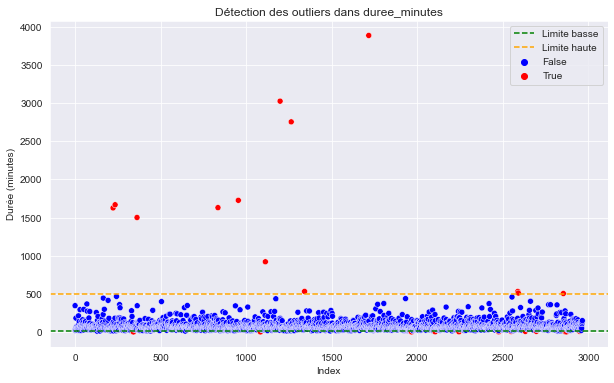

In [28]:
lower_bound = 10
upper_bound = 500

doubs_meteo["is_outlier"] = (doubs_meteo["duree_minutes"] < lower_bound) | (doubs_meteo["duree_minutes"] > upper_bound)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=doubs_meteo.index, y=doubs_meteo["duree_minutes"], hue=doubs_meteo["is_outlier"], palette={True: "red", False: "blue"})
plt.axhline(y=lower_bound, color='green', linestyle='--', label="Limite basse")
plt.axhline(y=upper_bound, color='orange', linestyle='--', label="Limite haute")
plt.xlabel("Index")
plt.ylabel("Durée (minutes)")
plt.title("Détection des outliers dans duree_minutes")
plt.legend()
plt.show()

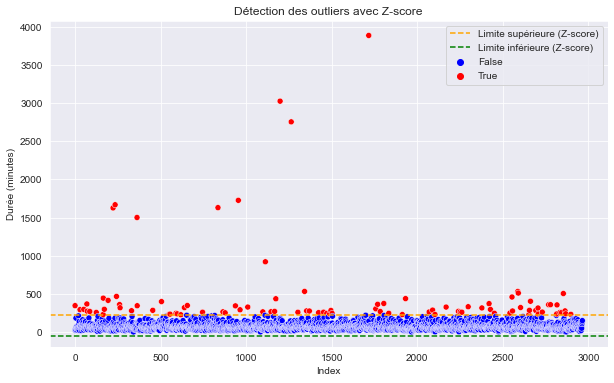

In [29]:
Z_THRESHOLD = 1

doubs_meteo["z_score"] = zscore(doubs_meteo["duree_minutes"])

doubs_meteo["is_outlier"] = abs(doubs_meteo["z_score"]) > Z_THRESHOLD

plt.figure(figsize=(10, 6))
sns.scatterplot(x=doubs_meteo.index, y=doubs_meteo["duree_minutes"], hue=doubs_meteo["is_outlier"], palette={True: "red", False: "blue"})

plt.axhline(y=doubs_meteo["duree_minutes"].mean() + Z_THRESHOLD * doubs_meteo["duree_minutes"].std(), color='orange', linestyle='--', label="Limite supérieure (Z-score)")
plt.axhline(y=doubs_meteo["duree_minutes"].mean() - Z_THRESHOLD * doubs_meteo["duree_minutes"].std(), color='green', linestyle='--', label="Limite inférieure (Z-score)")

plt.xlabel("Index")
plt.ylabel("Durée (minutes)")
plt.title("Détection des outliers avec Z-score")
plt.legend()
plt.show()

In [30]:
pd.set_option('display.max_rows', None)
print(doubs_meteo["duree_minutes"].sort_values())
pd.reset_option('display.max_rows')

341        0.366667
1083       1.150000
1966       1.266667
2871       1.416667
2865       1.850000
2104       2.716667
2475       2.733333
2243       2.850000
2548       7.516667
2631       7.750000
2695       8.516667
2948       9.033333
129       10.833333
2822      11.133333
644       11.583333
441       12.566667
145       12.983333
1491      13.383333
210       13.400000
1238      13.450000
224       14.183333
1383      14.216667
2836      14.300000
421       14.700000
2093      14.733333
2203      14.883333
929       15.716667
1613      16.066667
1261      16.116667
239       16.183333
2339      16.350000
1949      16.366667
1027      16.616667
849       16.766667
416       16.783333
1526      16.816667
1224      17.200000
760       17.266667
931       17.300000
2545      17.333333
1003      17.450000
1413      17.450000
1280      17.616667
440       17.716667
293       17.933333
2560      18.700000
2476      18.733333
2845      18.783333
494       18.816667
1125      18.966667


In [31]:
min_limit = 10
max_limit = 500

doubs_meteo["is_outlier"] = (doubs_meteo["duree_minutes"] < min_limit) | (doubs_meteo["duree_minutes"] > max_limit)

df_clean = doubs_meteo[~doubs_meteo["is_outlier"]].drop(columns=["is_outlier"])

df_clean = df_clean.dropna()

X = df_clean.drop(columns=["duree_minutes", 'hex_id', 'sinister'])
y = df_clean["duree_minutes"]

hex_ids = doubs_meteo['hex_id'].unique()

train_hex_ids, test_hex_ids = train_test_split(hex_ids, test_size=0.2, random_state=42)

train_data = doubs_meteo[doubs_meteo['hex_id'].isin(train_hex_ids)]
test_data = doubs_meteo[doubs_meteo['hex_id'].isin(test_hex_ids)]

train_data_clean = train_data[(train_data["duree_minutes"] >= min_limit) & (train_data["duree_minutes"] <= max_limit)]
test_data_clean = test_data[(test_data["duree_minutes"] >= min_limit) & (test_data["duree_minutes"] <= max_limit)]

X_train = train_data_clean.drop(columns=["duree_minutes", 'hex_id', 'sinister']).dropna()
y_train = train_data_clean["duree_minutes"]

X_test = test_data_clean.drop(columns=["duree_minutes", 'hex_id', 'sinister']).dropna()
y_test = test_data_clean["duree_minutes"]

xgb_model = XGBRegressor(objective='reg:squarederror', random_state=42)
xgb_model.fit(X_train, y_train)

y_pred = xgb_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)
r2 = r2_score(y_test, y_pred)

print(f"MAE : {mae:.2f} minutes")
print(f"MSE : {mse:.2f}")
print(f"RMSE : {rmse:.2f} minutes")
print(f"R² : {r2:.2f}")

MAE : 0.57 minutes
MSE : 2.19
RMSE : 1.48 minutes
R² : 1.00


   Z-score  Borne Inférieure  Borne Supérieure        MAE          MSE  \
0        1        -53.538377        226.001236  31.914025  1742.997852   
1        2       -193.308183        365.771043  43.054903  3330.484406   
2        3       -333.077990        505.540849  40.411964  3508.408949   
3        4       -472.847796        645.310656  42.201511  3593.585165   

        RMSE        R²  
0  41.749226  0.032643  
1  57.710349 -0.335102  
2  59.231824 -0.083628  
3  59.946519 -0.109936  


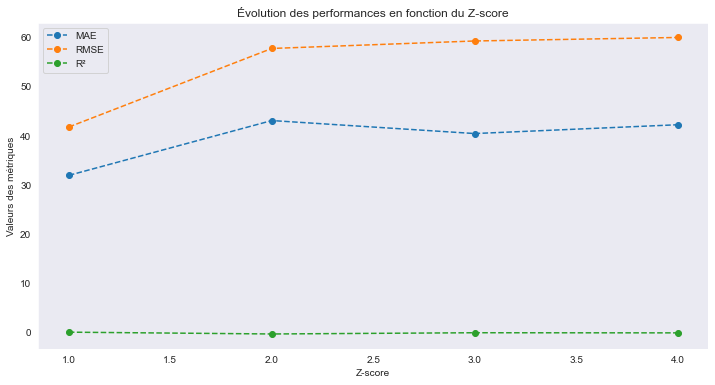

In [32]:
doubs_meteo["z_score"] = zscore(doubs_meteo["duree_minutes"])

mean_duree = doubs_meteo["duree_minutes"].mean()
std_duree = doubs_meteo["duree_minutes"].std()

z_thresholds = [1, 2, 3, 4]

results = []

for z_thresh in z_thresholds:
    lower_bound = mean_duree - (z_thresh * std_duree)
    upper_bound = mean_duree + (z_thresh * std_duree)

    df_clean = doubs_meteo[(doubs_meteo["duree_minutes"] >= lower_bound) &
                            (doubs_meteo["duree_minutes"] <= upper_bound)].copy()

    df_clean = df_clean.drop(columns=["z_score"]).dropna()

    unique_hex = df_clean["hex_id"].unique()
    hex_train, hex_test = train_test_split(unique_hex, test_size=0.2, random_state=42)

    train_data = df_clean[df_clean["hex_id"].isin(hex_train)]
    test_data = df_clean[df_clean["hex_id"].isin(hex_test)]

    X_train = train_data.drop(columns=["duree_minutes", "hex_id", "sinister"])
    y_train = train_data["duree_minutes"]
    X_test = test_data.drop(columns=["duree_minutes", "hex_id", "sinister"])
    y_test = test_data["duree_minutes"]

    xgb_model = XGBRegressor(objective='reg:squarederror', random_state=42)
    xgb_model.fit(X_train, y_train)

    y_pred = xgb_model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = mean_squared_error(y_test, y_pred, squared=False)
    r2 = r2_score(y_test, y_pred)

    results.append({"Z-score": z_thresh, "Borne Inférieure": lower_bound,
                    "Borne Supérieure": upper_bound, "MAE": mae, "MSE": mse,
                    "RMSE": rmse, "R²": r2})

results_df = pd.DataFrame(results)

print(results_df)

plt.figure(figsize=(12, 6))
plt.plot(results_df["Z-score"], results_df["MAE"], label="MAE", marker="o", linestyle="--")
plt.plot(results_df["Z-score"], results_df["RMSE"], label="RMSE", marker="o", linestyle="--")
plt.plot(results_df["Z-score"], results_df["R²"], label="R²", marker="o", linestyle="--")
plt.xlabel("Z-score")
plt.ylabel("Valeurs des métriques")
plt.title("Évolution des performances en fonction du Z-score")
plt.legend()
plt.grid()
plt.show()

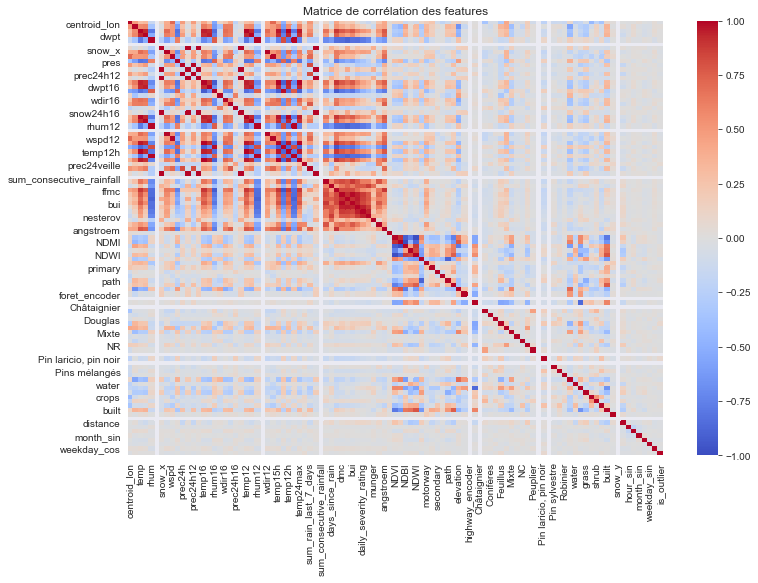

In [33]:
corr_matrix = X_train.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=False, cmap="coolwarm", center=0)
plt.title("Matrice de corrélation des features")
plt.show()

🛑 Suppression de 31 features corrélées: ['dwpt', 'snow24h', 'prec24h12', 'snow24h12', 'temp16', 'dwpt16', 'rhum16', 'snow24h16', 'temp12', 'dwpt12', 'rhum12', 'wdir12', 'wspd12', 'temp15h', 'rhum15h', 'temp12h', 'rhum12h', 'temp24max', 'sum_snow_last_7_days', 'ffmc', 'isi', 'bui', 'fwi', 'daily_severity_rating', 'nesterov', 'angstroem', 'NDMI', 'NDBI', 'NDWI', 'path', 'tree']
🛑 Suppression de 32 features corrélées: ['dwpt', 'snow24h', 'prec24h12', 'snow24h12', 'temp16', 'dwpt16', 'rhum16', 'snow24h16', 'temp12', 'dwpt12', 'rhum12', 'wdir12', 'wspd12', 'temp15h', 'rhum15h', 'temp12h', 'rhum12h', 'temp24max', 'sum_snow_last_7_days', 'ffmc', 'dmc', 'isi', 'bui', 'fwi', 'daily_severity_rating', 'nesterov', 'angstroem', 'NDMI', 'NDBI', 'NDWI', 'path', 'tree']
🛑 Suppression de 31 features corrélées: ['dwpt', 'snow24h', 'prec24h12', 'snow24h12', 'temp16', 'dwpt16', 'rhum16', 'snow24h16', 'temp12', 'dwpt12', 'rhum12', 'wdir12', 'wspd12', 'temp15h', 'rhum15h', 'temp12h', 'rhum12h', 'temp24max',

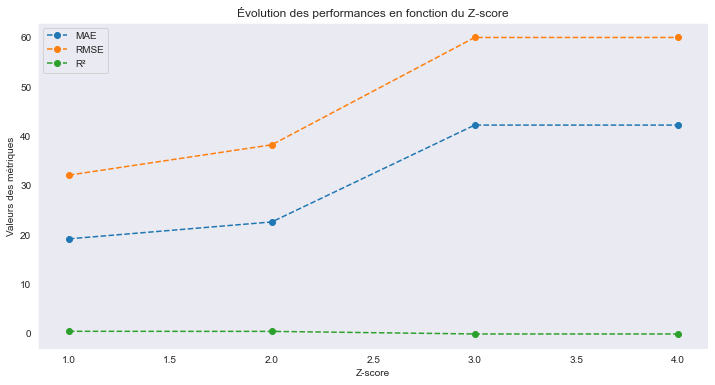

In [34]:
z_scores = np.abs(zscore(doubs_meteo["duree_minutes"]))
z_results = {}

z_thresholds = [1, 2, 3, 4]

results = []

for z_thresh in z_thresholds:
    lower_bound = mean_duree - (z_thresh * std_duree)
    upper_bound = mean_duree + (z_thresh * std_duree)

    df_clean = doubs_meteo[(doubs_meteo["duree_minutes"] >= lower_bound) &
                            (doubs_meteo["duree_minutes"] <= upper_bound)].copy()

    df_clean = df_clean.drop(columns=["z_score"]).dropna()

    unique_hex = df_clean["hex_id"].unique()
    hex_train, hex_test = train_test_split(unique_hex, test_size=0.2, random_state=42)

    train_data = df_clean[df_clean["hex_id"].isin(hex_train)]
    test_data = df_clean[df_clean["hex_id"].isin(hex_test)]

    X_train, y_train = train_data.drop(columns=["duree_minutes", "hex_id", "sinister"]), train_data["duree_minutes"]
    X_test, y_test = test_data.drop(columns=["duree_minutes", "hex_id", "sinister"]), test_data["duree_minutes"]

    X_train_filtered = remove_highly_correlated_features(X_train, threshold=0.85)
    X_test_filtered = X_test[X_train_filtered.columns]

    model = XGBRegressor(objective='reg:squarederror', random_state=42)
    model.fit(X_train_filtered, y_train)

    y_pred = xgb_model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = mean_squared_error(y_test, y_pred, squared=False)
    r2 = r2_score(y_test, y_pred)

    results.append({"Z-score": z_thresh, "Borne Inférieure": lower_bound,
                    "Borne Supérieure": upper_bound, "MAE": mae, "MSE": mse,
                    "RMSE": rmse, "R²": r2})

results_df = pd.DataFrame(results)

print(results_df)

plt.figure(figsize=(12, 6))
plt.plot(results_df["Z-score"], results_df["MAE"], label="MAE", marker="o", linestyle="--")
plt.plot(results_df["Z-score"], results_df["RMSE"], label="RMSE", marker="o", linestyle="--")
plt.plot(results_df["Z-score"], results_df["R²"], label="R²", marker="o", linestyle="--")
plt.xlabel("Z-score")
plt.ylabel("Valeurs des métriques")
plt.title("Évolution des performances en fonction du Z-score")
plt.legend()
plt.grid()
plt.show()

🛑 Suppression de 31 features corrélées: ['dwpt', 'snow24h', 'prec24h12', 'snow24h12', 'temp16', 'dwpt16', 'rhum16', 'snow24h16', 'temp12', 'dwpt12', 'rhum12', 'wdir12', 'wspd12', 'temp15h', 'rhum15h', 'temp12h', 'rhum12h', 'temp24max', 'sum_snow_last_7_days', 'ffmc', 'isi', 'bui', 'fwi', 'daily_severity_rating', 'nesterov', 'angstroem', 'NDMI', 'NDBI', 'NDWI', 'path', 'tree']
Meilleurs hyperparamètres pour Z-score = 1: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
🛑 Suppression de 32 features corrélées: ['dwpt', 'snow24h', 'prec24h12', 'snow24h12', 'temp16', 'dwpt16', 'rhum16', 'snow24h16', 'temp12', 'dwpt12', 'rhum12', 'wdir12', 'wspd12', 'temp15h', 'rhum15h', 'temp12h', 'rhum12h', 'temp24max', 'sum_snow_last_7_days', 'ffmc', 'dmc', 'isi', 'bui', 'fwi', 'daily_severity_rating', 'nesterov', 'angstroem', 'NDMI', 'NDBI', 'NDWI', 'path', 'tree']
Meilleurs hyperparamètres pour Z-score = 2: {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 200, 'subsam

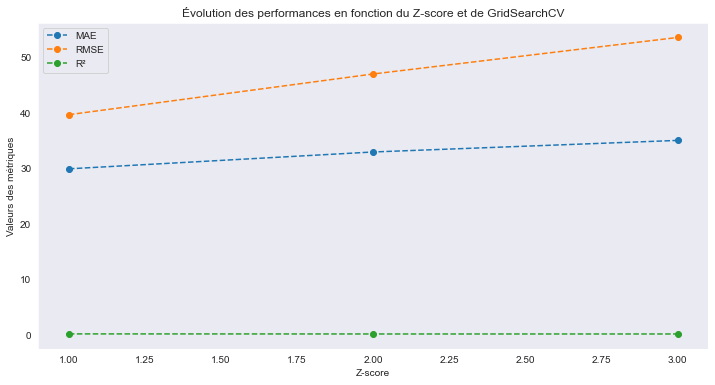

In [35]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
from scipy.stats import zscore

# Fonction pour supprimer les features trop corrélées
def remove_highly_correlated_features(X, threshold=0.85):
    corr_matrix = X.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]
    print(f"🛑 Suppression de {len(to_drop)} features corrélées: {to_drop}")
    return X.drop(columns=to_drop)

# GridSearchCV pour XGBRegressor
param_grid = {
    'n_estimators': [100, 200],  # Nombre d'arbres
    'max_depth': [3, 5],  # Profondeur des arbres
    'learning_rate': [0.01, 0.1],  # Taux d'apprentissage
    'subsample': [0.8, 1.0]  # Fraction des échantillons utilisés pour chaque arbre
}

# Filtrage des outliers avec Z-score (de 1 à 3)
z_scores = np.abs(zscore(doubs_meteo["duree_minutes"]))
z_results = []

z_thresholds = [1, 2, 3]

for z_thresh in z_thresholds:
    lower_bound = doubs_meteo["duree_minutes"].mean() - (z_thresh * doubs_meteo["duree_minutes"].std())
    upper_bound = doubs_meteo["duree_minutes"].mean() + (z_thresh * doubs_meteo["duree_minutes"].std())

    # Filtrage des outliers
    df_clean = doubs_meteo[(doubs_meteo["duree_minutes"] >= lower_bound) &
                            (doubs_meteo["duree_minutes"] <= upper_bound)].copy()

    df_clean = df_clean.drop(columns=["z_score"]).dropna()

    # Séparation des données train et test par hex_id
    unique_hex = df_clean["hex_id"].unique()
    hex_train, hex_test = train_test_split(unique_hex, test_size=0.2, random_state=42)

    train_data = df_clean[df_clean["hex_id"].isin(hex_train)]
    test_data = df_clean[df_clean["hex_id"].isin(hex_test)]

    X_train, y_train = train_data.drop(columns=["duree_minutes", "hex_id", "sinister"]), train_data["duree_minutes"]
    X_test, y_test = test_data.drop(columns=["duree_minutes", "hex_id", "sinister"]), test_data["duree_minutes"]

    # Suppression des features corrélées
    X_train_filtered = remove_highly_correlated_features(X_train, threshold=0.85)
    X_test_filtered = X_test[X_train_filtered.columns]

    # Définition du modèle
    model = XGBRegressor(objective='reg:squarederror', random_state=42)

    # GridSearchCV pour trouver les meilleurs hyperparamètres
    grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=3, n_jobs=-1, scoring='neg_mean_absolute_error')
    grid_search.fit(X_train_filtered, y_train)

    # Meilleurs hyperparamètres trouvés
    print(f"Meilleurs hyperparamètres pour Z-score = {z_thresh}: {grid_search.best_params_}")

    # Entraînement du modèle avec les meilleurs hyperparamètres
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test_filtered)

    # Évaluation
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    z_results.append({
        "Z-score": z_thresh, "Borne Inférieure": lower_bound,
        "Borne Supérieure": upper_bound, "MAE": mae, "MSE": mse,
        "RMSE": rmse, "R²": r2
    })

# Résultats
results_df = pd.DataFrame(z_results)
print(results_df)

# Visualisation des performances
plt.figure(figsize=(12, 6))
plt.plot(results_df["Z-score"], results_df["MAE"], label="MAE", marker="o", linestyle="--")
plt.plot(results_df["Z-score"], results_df["RMSE"], label="RMSE", marker="o", linestyle="--")
plt.plot(results_df["Z-score"], results_df["R²"], label="R²", marker="o", linestyle="--")
plt.xlabel("Z-score")
plt.ylabel("Valeurs des métriques")
plt.title("Évolution des performances en fonction du Z-score et de GridSearchCV")
plt.legend()
plt.grid()
plt.show()